> ## _🟩 1. Importar las librerías a utilizar_

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Entorno funcionando correctamente")

Entorno funcionando correctamente


> ## _🟦 2. Cargar el dataset en el notebook_

In [3]:
df = pd.read_csv("../data/ecommerce_sales_data.csv")
df.head()

,Order ID,Customer ID,Gender,Age,Product Category,Product Name,Quantity,Price,Order Date,Payment Method,City,Rating
0,ORD0001,CUST9376,Female,43,Home,Lamp,1,1368.69,07-06-2025,Cash on Delivery,Hyderabad,3
1,ORD0002,CUST3289,Male,57,Toys,Lego Set,5,782.44,11-12-2024,Cash on Delivery,Chennai,5
2,ORD0003,CUST6409,Female,53,Clothing,Jacket,1,3676.18,05-05-2025,Credit Card,Bangalore,4
3,ORD0004,CUST8815,Female,51,Beauty,Perfume,2,4836.37,25-06-2025,Cash on Delivery,Mumbai,5
4,ORD0005,CUST1018,Female,39,Electronics,Smartphone,4,3580.24,25-12-2024,UPI,Kolkata,3


> ## _🟧 3. Inspección inicial_

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order ID          100 non-null    object 
 1   Customer ID       100 non-null    object 
 2   Gender            100 non-null    object 
 3   Age               100 non-null    int64  
 4   Product Category  100 non-null    object 
 5   Product Name      100 non-null    object 
 6   Quantity          100 non-null    int64  
 7   Price             100 non-null    float64
 8   Order Date        100 non-null    object 
 9   Payment Method    100 non-null    object 
 10  City              100 non-null    object 
 11  Rating            100 non-null    int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 9.5+ KB


In [5]:
df.isna().sum()

Order ID            0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Product Name        0
Quantity            0
Price               0
Order Date          0
Payment Method      0
City                0
Rating              0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.describe()

,Age,Quantity,Price,Rating
count,100.000000,100.00000,100.000000,100.000000
mean,37.720000,2.94000,2428.300600,3.000000
std,12.426007,1.44124,1508.115395,1.392621
min,18.000000,1.00000,118.330000,1.000000
25%,28.000000,2.00000,1130.615000,2.000000
50%,37.500000,3.00000,2160.355000,3.000000
75%,49.000000,4.00000,3743.872500,4.000000
max,60.000000,5.00000,4836.370000,5.000000


In [9]:
df.columns

Index(['Order ID', 'Customer ID', 'Gender', 'Age', 'Product Category',
       'Product Name', 'Quantity', 'Price', 'Order Date', 'Payment Method',
       'City', 'Rating'],
      dtype='object')

In [11]:
# Función que normaliza los nombres de las coumnas a snake_case.
def reemplazar_espacios(lista_encabezados):
    return [
        encabezado.lower().replace(' ', '_').replace('.', '')
        for encabezado in lista_encabezados
    ]

df.columns = reemplazar_espacios(df.columns)
df.columns

Index(['order_id', 'customer_id', 'gender', 'age', 'product_category',
       'product_name', 'quantity', 'price', 'order_date', 'payment_method',
       'city', 'rating'],
      dtype='object')

> ## _🟪 4. Convertir columnas de fecha_

In [12]:
df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_id          100 non-null    object        
 1   customer_id       100 non-null    object        
 2   gender            100 non-null    object        
 3   age               100 non-null    int64         
 4   product_category  100 non-null    object        
 5   product_name      100 non-null    object        
 6   quantity          100 non-null    int64         
 7   price             100 non-null    float64       
 8   order_date        39 non-null     datetime64[ns]
 9   payment_method    100 non-null    object        
 10  city              100 non-null    object        
 11  rating            100 non-null    int64         
dtypes: datetime64[ns](1), float64(1), int64(3), object(7)
memory usage: 9.5+ KB


> ## _🟫 5. Crear columnas derivadas_

In [15]:
df['revenue'] = df['quantity'] * df['price']
df['order_month'] = df['order_date'].dt.to_period('M')

> ## _🟩 6. Métricas básicas de negocio_

In [17]:
# Ventas por mes.
df.groupby('order_month')['revenue'].sum()

order_month
2024-01     7540.71
2024-02     3957.46
2024-07    29808.55
2024-08    48631.42
2024-09    22221.50
2024-10    22762.10
2024-11     3912.20
2024-12     5303.48
2025-01     9592.05
2025-02    24943.32
2025-03     1992.12
2025-04     4470.26
2025-05    14565.42
2025-06    40945.65
2025-07     1368.69
2025-09     6093.46
2025-10     9503.24
2025-12     2068.90
Freq: M, Name: revenue, dtype: float64

In [22]:
# Los 10 productos mas vendidos.
df.groupby('product_name')['quantity'].sum().sort_values(ascending=False).head(10)

product_name
Smartphone    25
Curtains      25
Comics        23
Fiction       20
Smartwatch    19
T-Shirt       18
Perfume       17
Dress         16
Lego Set      16
Lamp          16
Name: quantity, dtype: int64

In [26]:
# Ticket promedio
round(df['revenue'].mean(), 2)

np.float64(6942.2)

In [29]:
df['customer_id'].nunique()

98

> ## _🟦 7. Primeros gráficos_

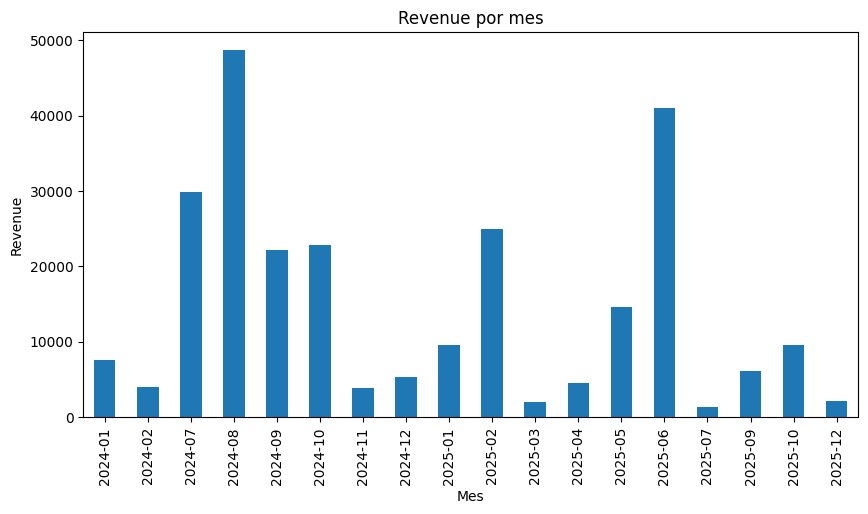

In [30]:
plt.figure(figsize=(10,5))
df.groupby('order_month')['revenue'].sum().plot(kind='bar')
plt.title("Revenue por mes")
plt.ylabel("Revenue")
plt.xlabel("Mes")
plt.show()